In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from camera_sensitivity import get_camera_sensitivity, get_camera_sensitivities
import matplotlib.pyplot as plt
import numpy as np

Loading from file


/tmp/ipykernel_2888801/3034448915.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=fs)


FileNotFoundError: [Errno 2] No such file or directory: 'thesis_figures/camera_sensitivities.pdf'

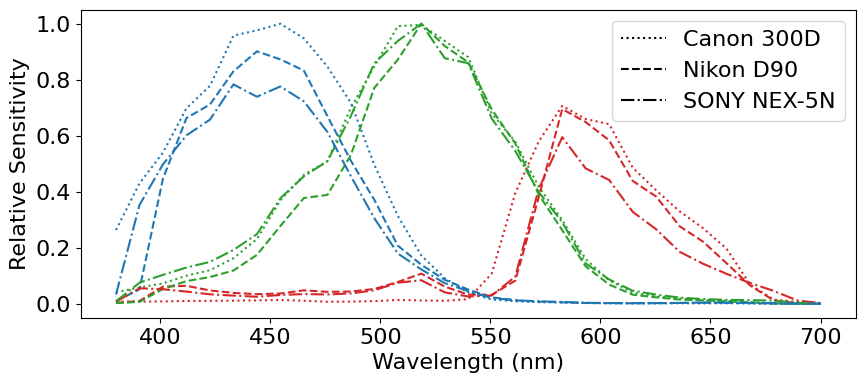

In [11]:
from matplotlib.lines import Line2D

models = ['Canon 300D', 'Nikon D90', 'SONY NEX-5N']
cam_bases = []
for model in models:
    cam_bases.append(get_camera_sensitivity(model))


wavelengths = np.linspace(380, 700, 31)

# Set figure size in inches to match document column width
fs = 16
styles = [':', '--', '-.']
fig = plt.figure(figsize=(10,4))
for idx, cam_basis in enumerate(cam_bases):
    
    plt.plot(wavelengths, cam_basis[:,0], linestyle=styles[idx], c='tab:red')
    plt.plot(wavelengths, cam_basis[:,1], linestyle=styles[idx], c='tab:green')
    plt.plot(wavelengths, cam_basis[:,2], linestyle=styles[idx], c='tab:blue')
plt.ylabel("Relative Sensitivity", fontsize=fs)
plt.xlabel("Wavelength (nm)", fontsize=fs)
plt.legend(fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

# create proxy artists for legend
legend_handles = [
    Line2D([0], [0], linestyle=styles[i], color='k', label=models[i])
    for i in range(len(models))
]

plt.legend(handles=legend_handles, fontsize=fs)

plt.savefig(f"thesis_figures/camera_sensitivities.pdf", bbox_inches="tight", pad_inches=0.02, dpi=300)
plt.savefig(f"thesis_figures/camera_sensitivities.png", bbox_inches="tight", pad_inches=0.02, dpi=300)


In [12]:
import matplotlib.font_manager as fm
names = {f.name for f in fm.fontManager.ttflist}
print("Times New Roman" in names, "Latin Modern Roman" in names, "Latin Modern Mono" in names)

False False False


# Look at more camera sensitivities


dict_keys(['Canon 1DMarkIII', 'Canon 20D', 'Canon 300D', 'Canon 40D', 'Canon 500D', 'Canon 50D', 'Canon 5DMarkII', 'Canon 600D', 'Canon 60D', 'Hasselblad H2', 'Nikon D3X', 'Nikon D200', 'Nikon D3', 'Nikon D300s', 'Nikon D40', 'Nikon D50', 'Nikon D5100', 'Nikon D700', 'Nikon D80', 'Nikon D90', 'Nokia N900', 'Olympus E-PL2', 'Pentax K-5', 'Pentax Q', 'Point Grey Grasshopper 50S5C', 'Point Grey Grasshopper2 14S5C', 'Phase One', 'SONY NEX-5N'])


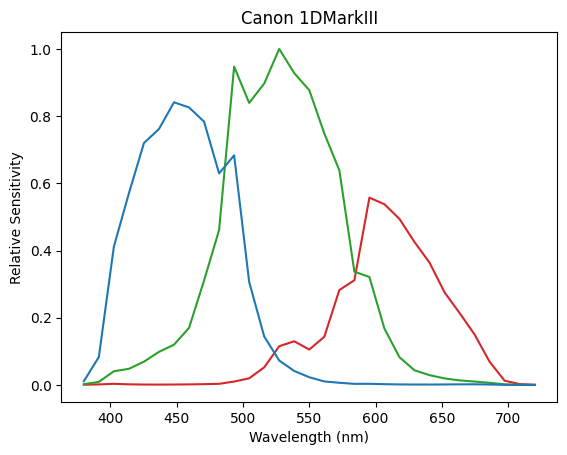

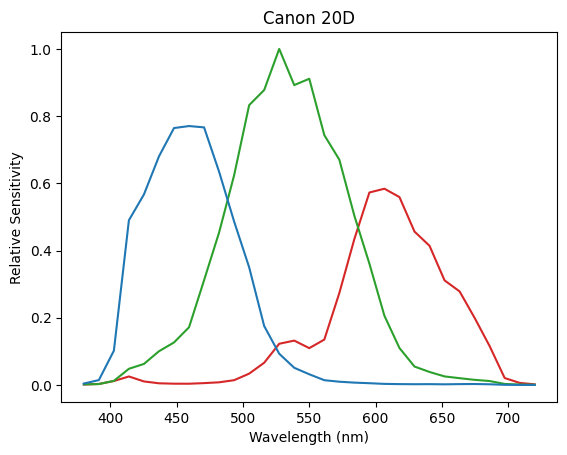

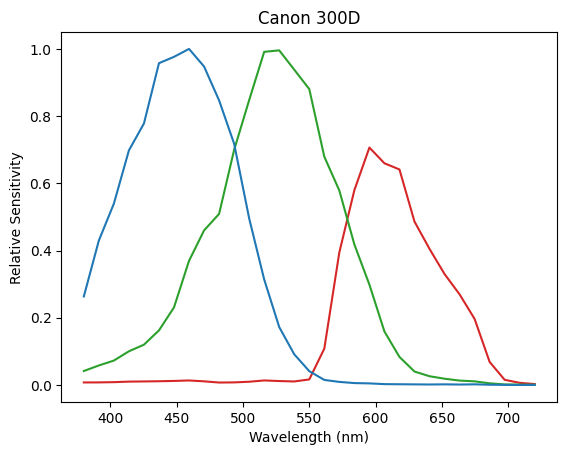

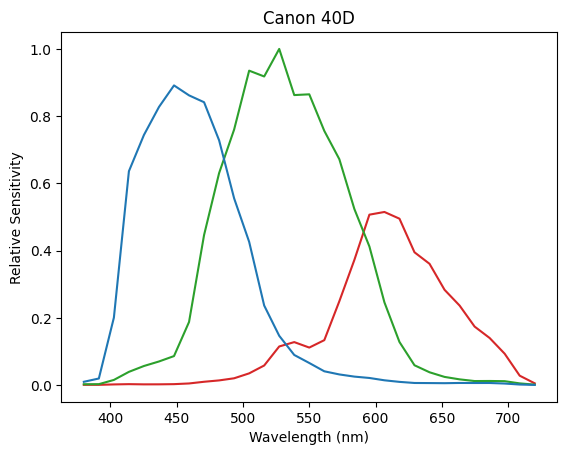

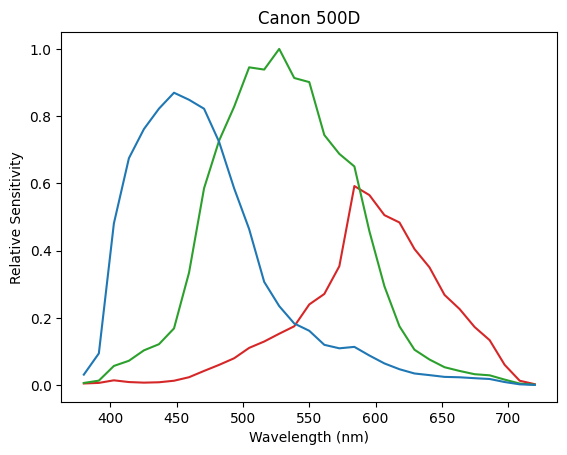

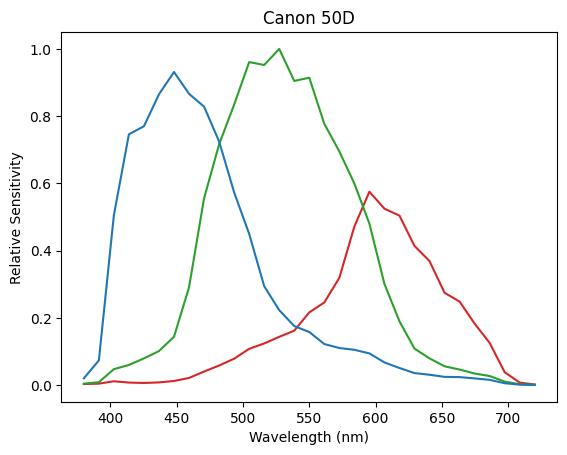

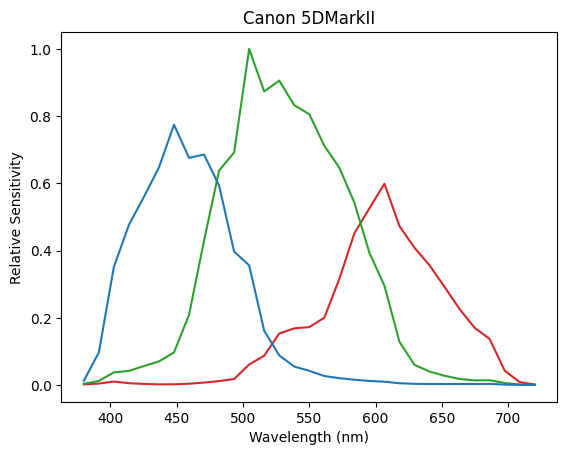

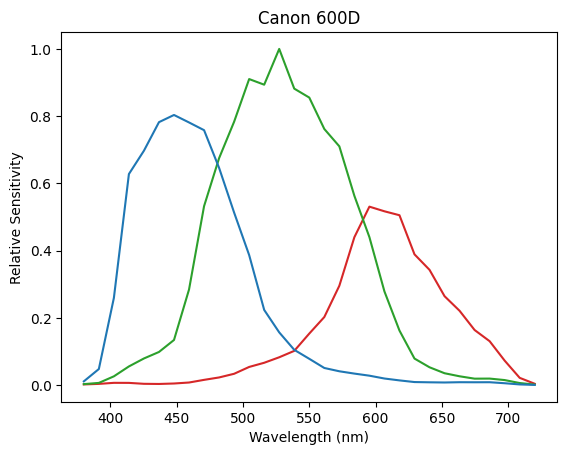

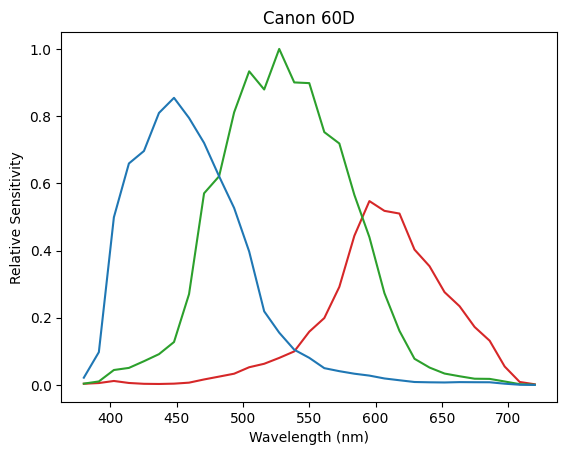

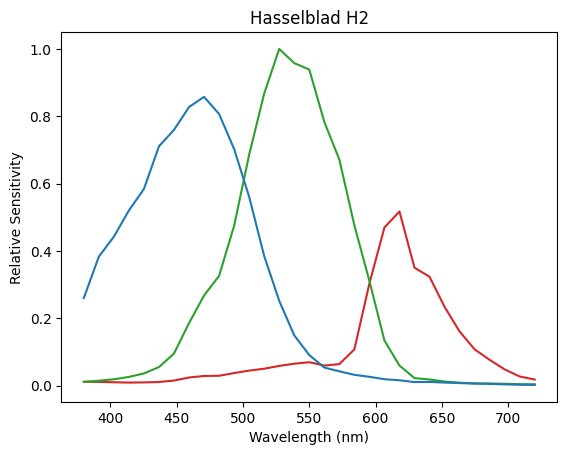

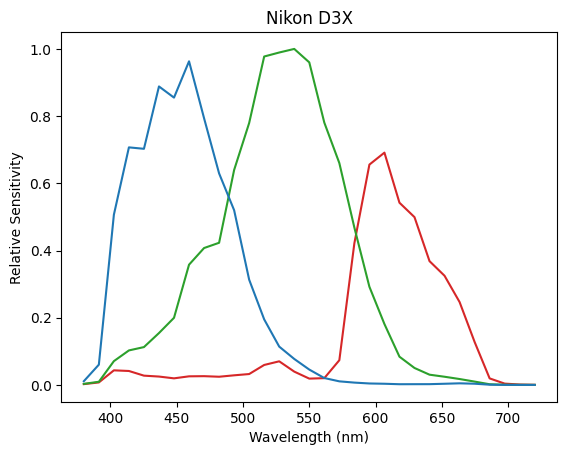

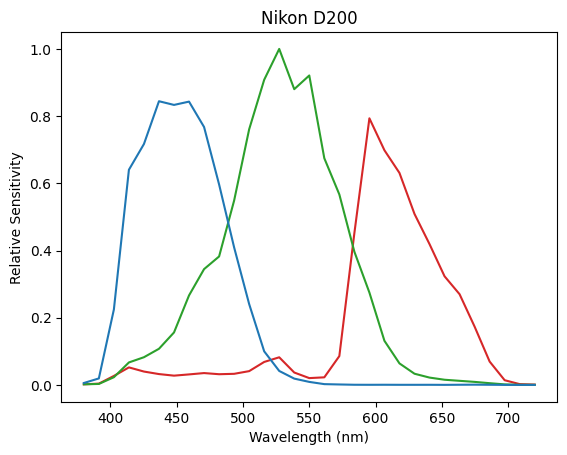

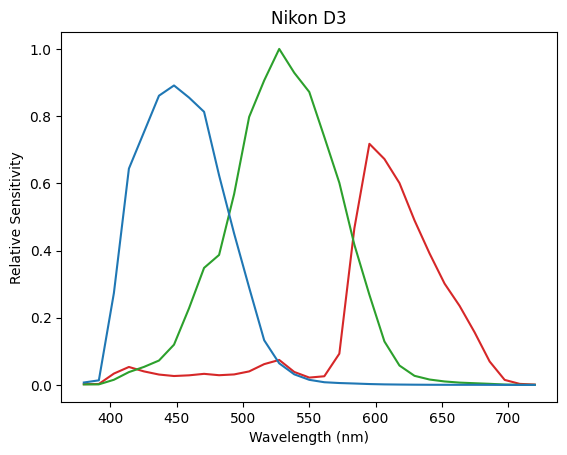

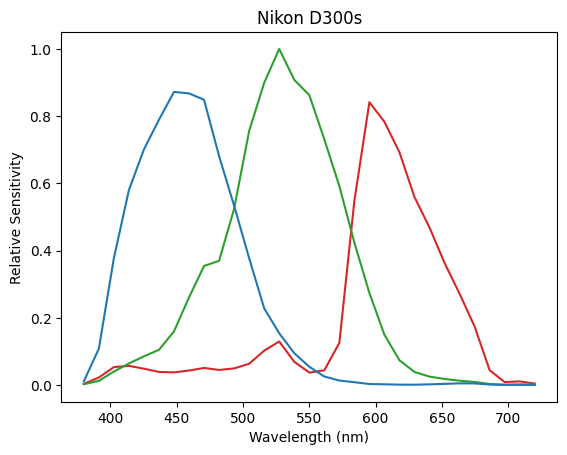

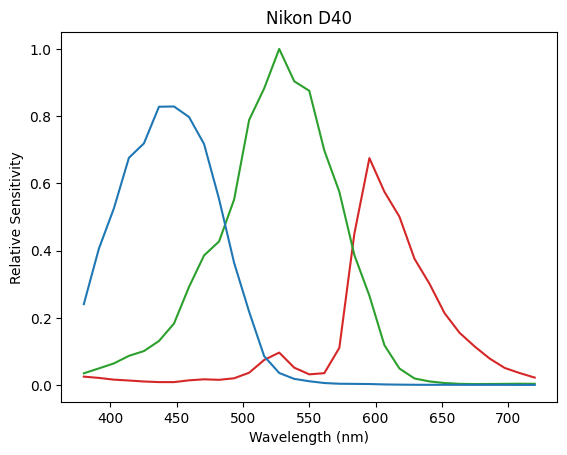

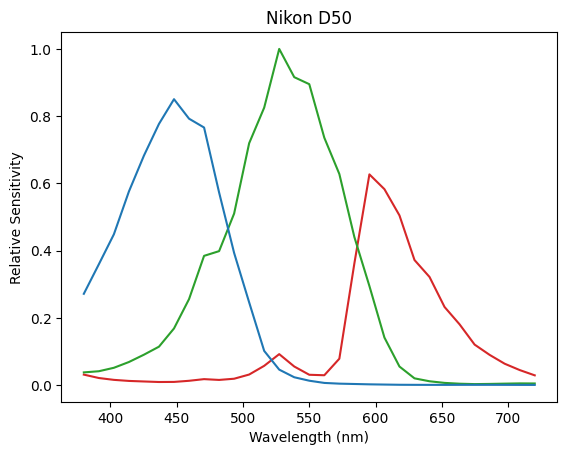

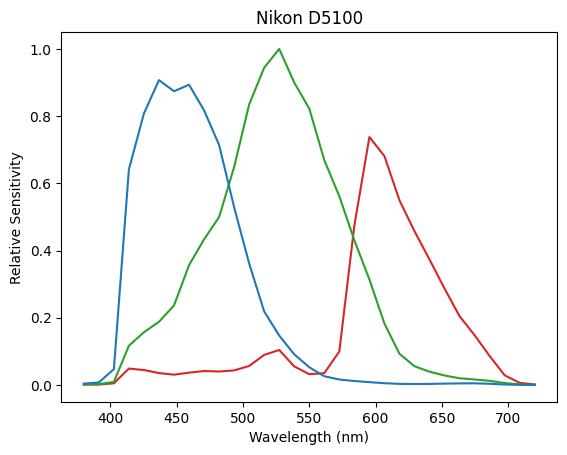

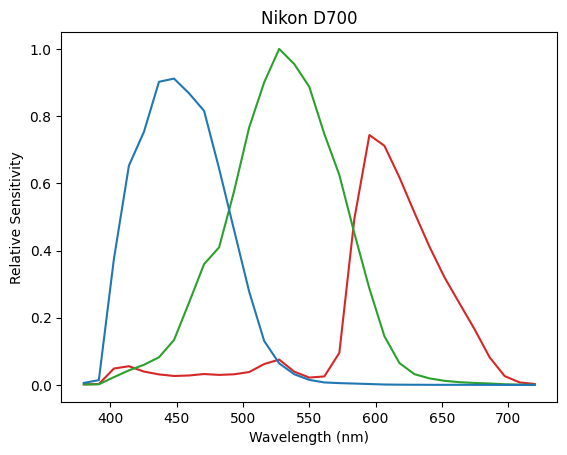

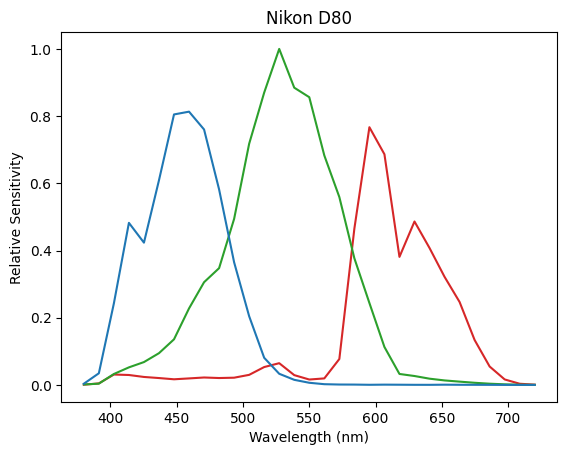

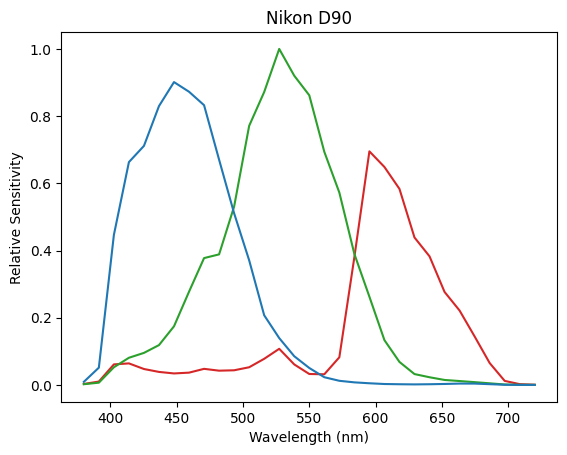

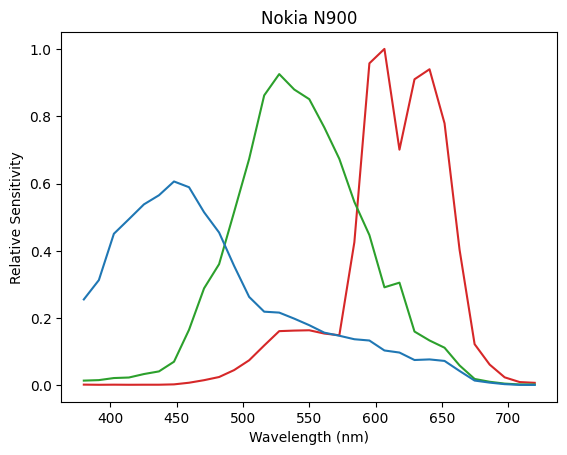

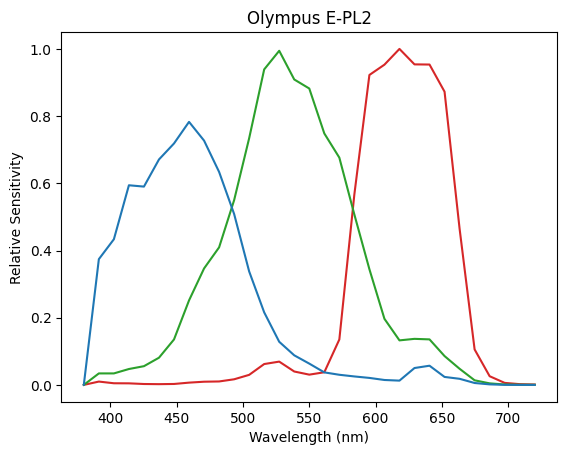

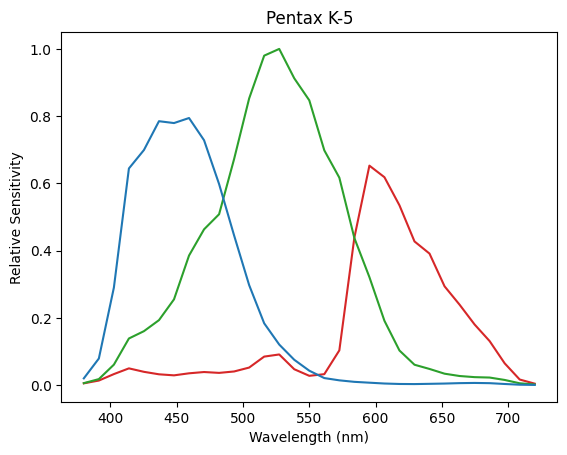

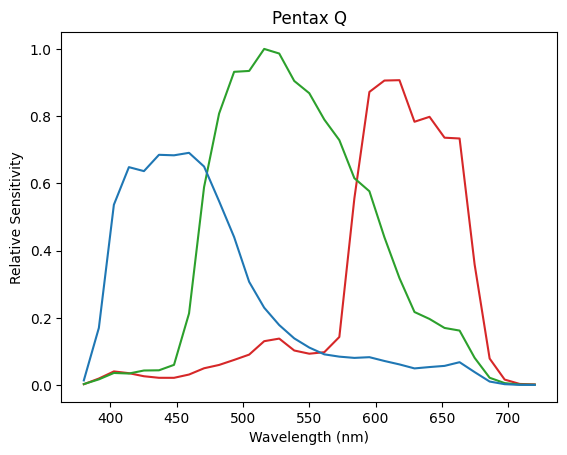

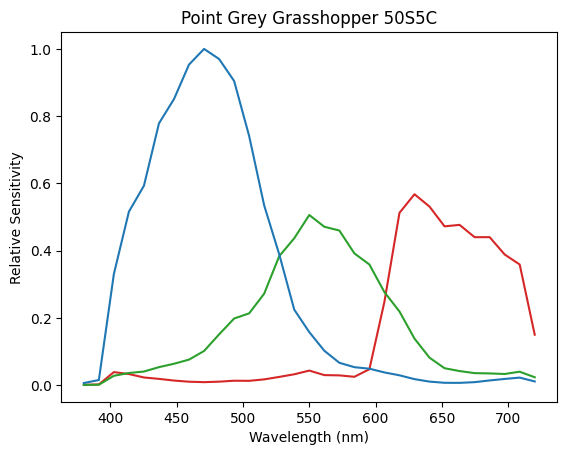

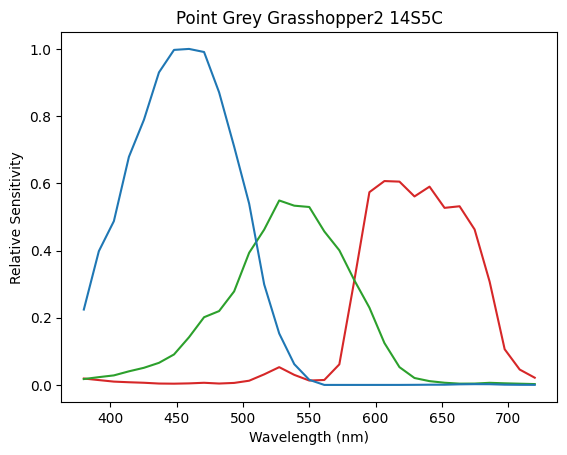

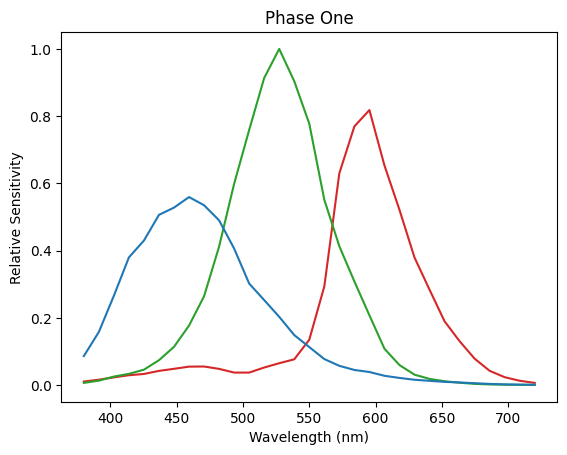

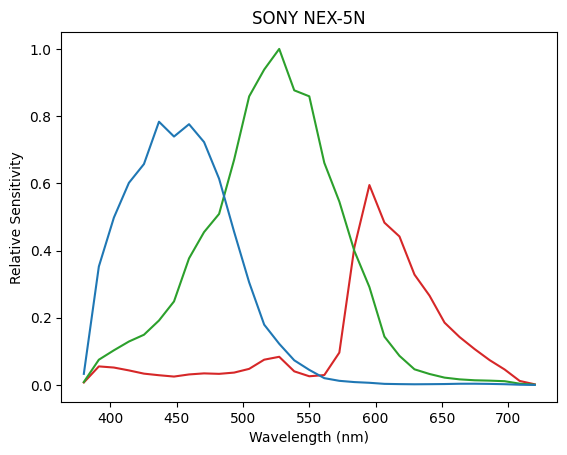

In [13]:
def plot_camera_sensitivities(name, sensitivities):
    wavelengths = np.linspace(380, 720, 31)
    
    # Set figure size in inches to match document column width
    plt.plot(wavelengths, sensitivities[:,0], 'tab:red', label='Red')
    plt.plot(wavelengths, sensitivities[:,1], 'tab:green', label='Green')
    plt.plot(wavelengths, sensitivities[:,2], 'tab:blue', label='Blue')
    plt.ylabel("Relative Sensitivity")
    plt.xlabel("Wavelength (nm)")
    plt.title(name)
    plt.show()
camera_sensitivities = get_camera_sensitivities()
print(camera_sensitivities.keys())
for camera_name, sensitivities in camera_sensitivities.items():
    plot_camera_sensitivities(camera_name, sensitivities)